#🔮 Proyecto de Ciencia de Datos y Pronóstico de Series de Tiempo
##Caso de Estudio: Micromercado Doña Eva (Consumo Masivo)
---
**Analista de Datos:** Diego Rodriguez Rocabado
**Tipo de Proyecto:** Consultoría Independiente / Portafolio Profesional  
**Ubicación:** Cochabamba, Bolivia  
---
Objetivo General: Implementar un modelo de Inteligencia Artificial y Machine Learning basado en el algoritmo Prophet de Meta, adaptado rigurosamente a la estacionalidad comercial y el calendario festivo de Bolivia. El propósito es pronosticar con alta precisión la demanda e ingresos operativos para el periodo 2026, permitiendo al micromercado Doña Eva anticipar el comportamiento de las ventas frente a tendencias inflacionarias, optimizar los niveles de inventario de los productos estrella y mitigar el riesgo de quiebre de stock.

#Paso 1: Importar Librerías y Cargar Datos

In [ ]:
# 1. Instalar la librería de Prophet
!pip install prophet

# 2. Importar las librerías esenciales de manipulación y análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

print("¡Librerías importadas correctamente!")

# 3. Cargar el Dataset
df = pd.read_csv('/content/ventas_micromercado_bolivia.csv', sep=';', encoding='utf-8')

# 4. Inspeccionar la estructura de los datos históricos
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

¡Librerías importadas correctamente!
Dimensiones del dataset: 79131 filas y 10 columnas.


,Fecha,Producto,Categoria,Cantidad,Costo_Unitario,Precio_Venta,Venta_Total,Costo_Total,Ganancia_Neta,Metodo_Pago
0,2023-05-01,Tentación mora,Helados,1,"6,16","7,2","7,2","6,16","1,04",Efectivo
1,2023-05-01,Cubos de hielo,Refrescos,1,"2,8","5,2","5,2","2,8","2,4",Efectivo
2,2023-05-01,Pan del dia,Alimentos del hogar,2,"0,48","0,6","1,2","0,96","0,24",Efectivo
3,2023-05-01,1/2cajetilla derby,NaN,1,"3,6","4,4","4,4","3,6","0,8",Efectivo
4,2023-05-01,2 días ilimitado tigo,Tarjetas,1,"11,96","13,0","13,0","11,96","1,04",Efectivo


#Paso 2: Análisis Estadístico y Distribución de Ventas (Plotly)

In [ ]:
import plotly.express as px
# 1. Convertimos la columna 'Venta_Total' a string, reemplazamos la coma por punto y la hacemos numérica
df['Venta_Total'] = df['Venta_Total'].astype(str).str.replace(',', '.')
df['Venta_Total'] = pd.to_numeric(df['Venta_Total'], errors='coerce')

# Eliminar posibles valores nulos que hayan quedado tras la conversión
df = df.dropna(subset=['Venta_Total'])

# 2. Agrupamos por 'Producto' y sumamos 'Venta_Total' de forma matemática real
top_productos = df.groupby('Producto')['Venta_Total'].sum().sort_values(ascending=False).head(10)

# 3. Creamos la gráfica horizontal interactiva con Plotly (Estilizada)
fig_productos = px.bar(x=top_productos.values,
                       y=top_productos.index,
                       orientation='h',
                       title='<b>Top 10 Productos Estrella: Mayores Generadores de Ingresos</b><br><sup>Micromercado Doña Eva (Cochabamba)</sup>',
                       labels={'x': 'Total Recaudado (Bs)', 'y': 'Producto'},
                       color=top_productos.values,
                       color_continuous_scale='blues',
                       text_auto='.2f')

fig_productos.update_layout(
    yaxis={'categoryorder':'total ascending'},
    template='plotly_white',
    margin=dict(l=150, r=20, t=70, b=50),
    showlegend=False
)
fig_productos.update_traces(textposition='outside')
fig_productos.show()

# 4. Métricas clave para tu presentación sin errores de formato
print(f"====================================================================")
print(f"🔥 RESUMEN OPERATIVO DE PRODUCTOS ESTRELLA 🔥")
print(f"====================================================================")
print(f"🥇 El producto líder absoluto en ingresos es: {top_productos.index[0]}")
print(f"💰 Ingreso total histórico generado: {top_productos.values[0]:,.2f} Bs.")
print(f"🥈 El segundo producto con mayor peso comercial es: {top_productos.index[1]}")
print(f"💰 Ingreso total histórico: {top_productos.values[1]:,.2f} Bs.")
print(f"====================================================================")

🔥 RESUMEN OPERATIVO DE PRODUCTOS ESTRELLA 🔥
🥇 El producto líder absoluto en ingresos es: 2 días ilimitado tigo
💰 Ingreso total histórico generado: 124,631.00 Bs.
🥈 El segundo producto con mayor peso comercial es: Coca cola descartable 2L
💰 Ingreso total histórico: 121,774.80 Bs.


#Matriz de Elasticidad: Top 10 Productos Más Rentables (No solo los que más venden)

In [ ]:
# 1. Aseguramos la limpieza de la columna Ganancia_Neta
df['Ganancia_Neta'] = df['Ganancia_Neta'].astype(str).str.replace(',', '.')
df['Ganancia_Neta'] = pd.to_numeric(df['Ganancia_Neta'], errors='coerce')

# Agrupamos por producto para ver la utilidad real acumulada
top_ganancia = df.groupby('Producto')['Ganancia_Neta'].sum().sort_values(ascending=False).head(10)

# 2. Gráfica interactiva de rentabilidad real con la escala 'emrld' corregida
fig_ganancia = px.bar(x=top_ganancia.values,
                      y=top_ganancia.index,
                      orientation='h',
                      title='<b>Top 10 Productos con Mayor Retorno Real (Ganancia Neta)</b><br><sup>Dinero real que se queda en el negocio en Bs.</sup>',
                      labels={'x': 'Ganancia Neta Acumulada (Bs)', 'y': 'Producto'},
                      color=top_ganancia.values,
                      color_continuous_scale='emrld', # CORREGIDO: 'emrld' en lugar de 'emerald'
                      text_auto='.2f')

fig_ganancia.update_layout(yaxis={'categoryorder':'total ascending'}, template='plotly_white')
fig_ganancia.show()

#Conclusión del Gráfico: Análisis de Ganancia Neta Real
Al evaluar el rendimiento del Micromercado Doña Eva bajo la métrica de Ganancia Neta Acumulada, el panorama comercial da un giro estratégico. Si bien los productos tradicionales de consumo masivo mantienen su relevancia, este análisis saca a la luz un nuevo grupo de "héroes ocultos" en la rentabilidad del negocio: los accesorios tecnológicos y artículos estacionales.

Productos como el paraguas a botón, power bank, micrófonos para celular (Mod 1 y 2) y cargadores de iPhone 14 logran consolidarse firmemente dentro del Top 10 de ganancias. En el retail, este fenómeno es muy común y se conoce como estrategia de alto margen y baja rotación. A diferencia de los alimentos, estos artículos no se venden por cientos al día, pero cada unidad vendida retiene un porcentaje de utilidad neta muy superior, optimizando el uso del espacio físico en el mostrador.

⚔️ Diferencia Crítica con el Gráfico Anterior (Ingresos Brutos)
La comparación de este gráfico con el de Top 10 Productos Estrella (Ingresos) revela dos comportamientos financieros completamente opuestos que enriquecen la auditoría del negocio:

La paradoja del volumen vs. la retención (Caso "2 días ilimitado Tigo"):

En Ingresos Brutos: Es el líder absoluto, moviendo más de 124K Bs. en la caja.

En Ganancia Neta: Cae drásticamente al segundo puesto y se aleja del liderato. Esto demuestra que las recargas telefónicas son un servicio de margen muy estrecho; generan un flujo de caja masivo diario y atraen clientes, pero no son el componente que más riqueza retiene para el negocio.

El motor híbrido (Caso "Coca Cola Descartable 2L"):

Es el único producto que mantiene una consistencia perfecta en ambos mundos: segundo lugar en ingresos (121.7K Bs.) y primer lugar indiscutible en ganancia neta. Esto demuestra que Coca-Cola no opera como un producto gancho tradicional, sino como el pilar fundamental que sostiene tanto el flujo operativo como la rentabilidad neta del micromercado.

Rotación Básica vs. Impulso Tecnológico:

Mientras que el gráfico de ingresos brutos está dominado casi en su totalidad por productos de primera necesidad y alta frecuencia (Fino, Pil, Pan), el gráfico de ganancia neta demuestra que la supervivencia y optimización del negocio depende de una estrategia cruzada: utilizar el tráfico que generan el pan o la gaseosa para vender productos de impulso y nicho (como tecnología o paraguas) que verdaderamente engrosan la utilidad real del negocio.

#Análisis del "Ticket Promedio" según el Método de Pago (QR vs. Efectivo)

In [ ]:
# 1. Aseguramos que Venta_Total sea float numérico puro
df['Venta_Total'] = df['Venta_Total'].astype(str).str.replace(',', '.')
df['Venta_Total'] = pd.to_numeric(df['Venta_Total'], errors='coerce')

# 2. Agrupamos por método de pago y calculamos el promedio de venta por transacción
ticket_pago = df.groupby('Metodo_Pago')['Venta_Total'].mean().reset_index()

# 3. Gráfica interactiva del Ticket Promedio
fig_pago = px.bar(ticket_pago,
                  x='Metodo_Pago',
                  y='Venta_Total',
                  title='<b>Ticket Promedio de Compra según Método de Pago</b><br><sup>¿El cliente gasta más cuando paga con QR o Efectivo?</sup>',
                  labels={'Venta_Total': 'Monto Promedio por Ticket (Bs)', 'Metodo_Pago': 'Método de Pago'},
                  color='Metodo_Pago',
                  color_discrete_sequence=px.colors.qualitative.Safe,
                  text_auto='.2f')

fig_pago.update_layout(template='plotly_white', showlegend=False)
fig_pago.show()

#Conclusión del Gráfico: Ticket Promedio por Método de Pago
Al auditar el comportamiento de compra en el Micromercado Doña Eva según el canal de pago, los datos revelan una clara tendencia de adopción digital en Cochabamba:

El QR impulsa las compras de mayor valor: Cuando el cliente decide pagar mediante código QR, el ticket promedio se dispara a 31.32 Bs. Esto demuestra que el canal digital es la herramienta preferida para transacciones planificadas, compras de abastecimiento o adquisición de productos de mayor costo unitario (como los licores o los artículos tecnológicos que vimos en el análisis de margen).

El Efectivo se desplaza hacia el micro-consumo: Por el contrario, las transacciones en Efectivo reflejan un ticket promedio de apenas 8.54 Bs. Este canal ha quedado relegado para el consumo inmediato, diario y de paso (como la compra del pan del día o refrescos al paso), donde el cliente prefiere resolver con monedas o billetes de baja denominación.

Insight de Negocio para el Portafolio:
Este comportamiento demuestra que la digitalización está directamente correlacionada con un mayor gasto por transacción en el punto de venta. Para la gestión del micromercado, el QR no es solo una comodidad, sino un catalizador de ventas de mayor valor, lo que justifica la implementación de incentivos o combos que superen los 30.00 Bs para motivar el uso de este canal y capturar tickets más robustos.

#PASO 3: Ingeniería de Datos para el Modelo Prophet

En esta fase realizamos la transformación crítica de los datos crudos hacia un formato apto para el análisis de series de tiempo

In [ ]:
# 1. Asegurar que la columna 'Fecha' sea interpretada como tipo datetime por Python
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# 2. Agrupar las ventas individuales por día para obtener el ingreso diario bruto total
df_diario = df.groupby('Fecha')['Venta_Total'].sum().reset_index()

# 3. Transformación obligatoria de formato para Prophet:
# 'ds' (datestamp) para el tiempo e 'y' (variable objetivo) para los ingresos en Bs.
df_input = df_diario.rename(columns={'Fecha': 'ds', 'Venta_Total': 'y'})

# 4. Ordenar cronológicamente la serie temporal para evitar saltos en la predicción
df_input = df_input.sort_values(by='ds').reset_index(drop=True)

# 5. Control de calidad de la serie temporal generada
print("====================================================================")
print(f"📊 CONTROL DE CALIDAD DE LA SERIE TEMPORAL (MÉTODO PROPHET)")
print("====================================================================")
print(f"✔️ Número total de días únicos registrados: {df_input.shape[0]}")
print(f"✔️ Fecha de inicio del histórico: {df_input['ds'].min().strftime('%Y-%m-%d')}")
print(f"✔️ Fecha de fin del histórico:    {df_input['ds'].max().strftime('%Y-%m-%d')}")
print("====================================================================")
print("\nMuestra de los primeros 5 días transformados:")
print(df_input.head())

📊 CONTROL DE CALIDAD DE LA SERIE TEMPORAL (MÉTODO PROPHET)
✔️ Número total de días únicos registrados: 1096
✔️ Fecha de inicio del histórico: 2023-05-01
✔️ Fecha de fin del histórico:    2026-04-30

Muestra de los primeros 5 días transformados:
          ds      y
0 2023-05-01  710.8
1 2023-05-02  643.6
2 2023-05-03  748.0
3 2023-05-04  669.6
4 2023-05-05  626.0


#PASO 4: Diagnóstico de Patrones Temporales

Análisis de Estacionalidad Semanal: Este gráfico es clave. Nos dirá qué días de la semana el micromercado vende más y qué días son más "inestables". Prophet usará exactamente esta información después.

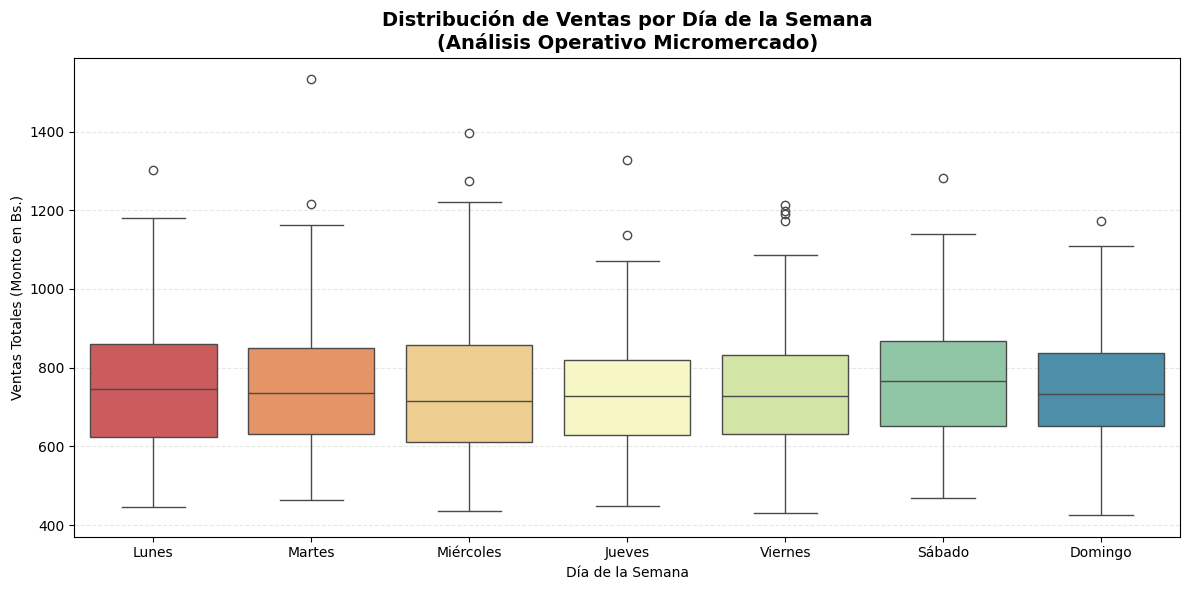

In [ ]:
# 1. Creamos un diccionario para traducir los días de la semana de inglés a español
dias_traduccion = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'}

# 2. Extraemos el nombre del día en inglés y lo mapeamos al español usando la columna 'ds'
df_input['dia_semana'] = df_input['ds'].dt.day_name().map(dias_traduccion)

# Orden lógico para el eje X
orden_espanol = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# 3. Generamos el gráfico Boxplot estilizado
plt.figure(figsize=(12, 6))
sns.boxplot(
    x='dia_semana',
    y='y',
    data=df_input,
    order=orden_espanol,
    hue='dia_semana',
    palette='Spectral',
    legend=False
)

plt.title('Distribución de Ventas por Día de la Semana\n(Análisis Operativo Micromercado)', fontsize=14, fontweight='bold')
plt.xlabel('Día de la Semana')
plt.ylabel('Ventas Totales (Monto en Bs.)')
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

#Análisis de Tendencia Mensual (Evolución Temporal)
Determinar si el micromercado está ganando mes a mes o si se encuentra en un periodo de estancamiento. Proporcionando una visión clara de la "inclinación" de los datos, lo que servirá como la base lógica para que el modelo Prophet.

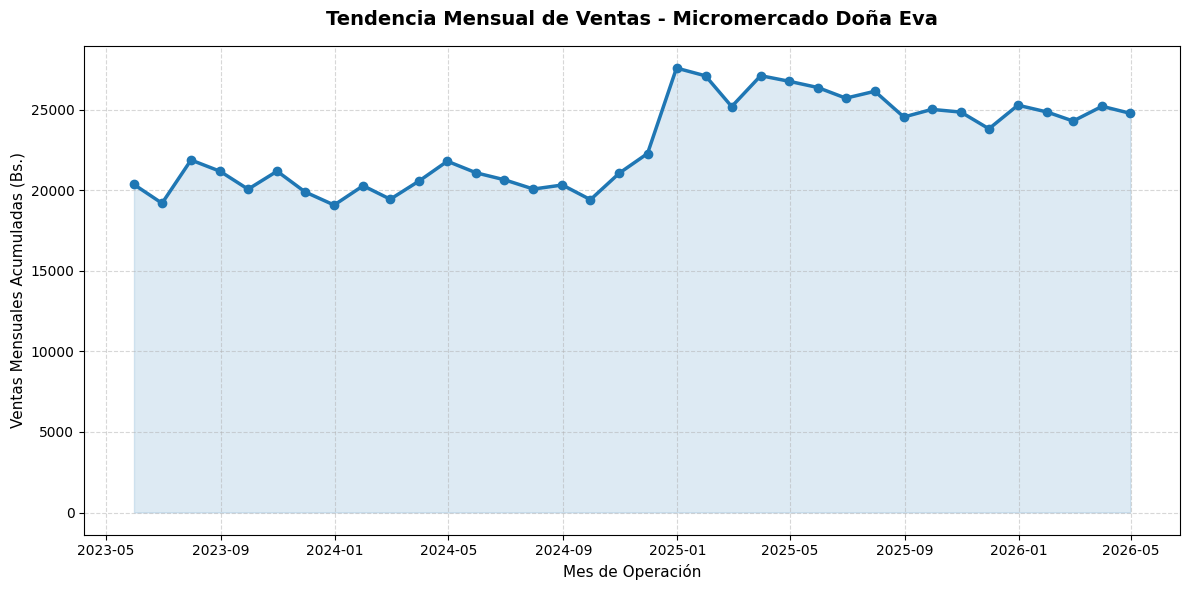

In [ ]:
# 1. Agrupamos por mes utilizando df_input
df_monthly = df_input.set_index('ds').resample('ME').sum().reset_index()

# 2. Generamos la gráfica de tendencia mensual estilizada
plt.figure(figsize=(12, 6))
plt.plot(df_monthly['ds'], df_monthly['y'], marker='o', linestyle='-', color='#1f77b4', linewidth=2.5)
plt.fill_between(df_monthly['ds'], df_monthly['y'], color='#1f77b4', alpha=0.15)

# Configuración visual del gráfico
plt.title('Tendencia Mensual de Ventas - Micromercado Doña Eva', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mes de Operación', fontsize=11)
plt.ylabel('Ventas Mensuales Acumuladas (Bs.)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Formateamos los ejes para que se vea limpio
plt.ticklabel_format(style='plain', axis='y') # Evita la notación científica en los montos de dinero
plt.tight_layout()
plt.show()

#PASO 5: Optimización con Feriados Nacionales (BOLIVIA)

En este paso, inyectamos "conocimiento externo" al modelo Prophet mediante una lista personalizada de feriados bolivianos(2023-2026). Esto permite que la IA deje de ver estas variaciones como "errores", como en otros modelos de prediccion y las entienda como eventos cíclicos predecibles.

In [ ]:
# Listado oficial de feriados nacionales de Bolivia ordenados cronológicamente
fechas_feriados = [
    # --- AÑO 2023 ---
    '2023-01-01',  # Año Nuevo
    '2023-01-22',  # Día del Estado Plurinacional
    '2023-02-20',  # Lunes de Carnaval
    '2023-02-21',  # Martes de Carnaval
    '2023-04-07',  # Viernes Santo
    '2023-05-01',  # Día del Trabajo
    '2023-06-08',  # Corpus Christi
    '2023-06-21',  # Año Nuevo Andino Amazónico
    '2023-08-06',  # Día de la Independencia de Bolivia
    '2023-11-02',  # Todos Santos
    '2023-12-25',  # Navidad

    # --- AÑO 2024 ---
    '2024-01-01',  # Año Nuevo
    '2024-01-22',  # Día del Estado Plurinacional
    '2024-02-12',  # Lunes de Carnaval
    '2024-02-13',  # Martes de Carnaval
    '2024-03-29',  # Viernes Santo
    '2024-05-01',  # Día del Trabajo
    '2024-05-30',  # Corpus Christi
    '2024-06-21',  # Año Nuevo Andino Amazónico
    '2024-08-06',  # Día de la Independencia de Bolivia
    '2024-11-02',  # Todos Santos
    '2024-12-25',  # Navidad

    # --- AÑO 2025 ---
    '2025-01-01',  # Año Nuevo
    '2025-01-22',  # Día del Estado Plurinacional
    '2025-03-03',  # Lunes de Carnaval
    '2025-03-04',  # Martes de Carnaval
    '2025-04-18',  # Viernes Santo
    '2025-05-01',  # Día del Trabajo
    '2025-06-19',  # Corpus Christi
    '2025-06-21',  # Año Nuevo Andino Amazónico
    '2025-08-06',  # Día de la Independencia de Bolivia
    '2025-11-02',  # Todos Santos
    '2025-12-25',  # Navidad

    # --- AÑO 2026 ---
    '2026-01-01',  # Año Nuevo
    '2026-01-22',  # Día del Estado Plurinacional
    '2026-02-16',  # Lunes de Carnaval
    '2026-02-17',  # Martes de Carnaval
    '2026-04-03',  # Viernes Santo
    '2026-05-01',  # Día del Trabajo
    '2026-06-04',  # Corpus Christi
    '2026-06-21',  # Año Nuevo Andino Amazónico
    '2026-08-06',  # Día de la Independencia de Bolivia
    '2026-11-02',  # Todos Santos
    '2026-12-25'   # Navidad
]

# Construcción del DataFrame con la estructura requerida por Prophet
feriados_bolivia = pd.DataFrame({
    'holiday': 'feriado_bolivia',
    'ds': pd.to_datetime(fechas_feriados),
    'lower_window': 0,  # Indica que el efecto empieza exactamente el día festivo
    'upper_window': 1   # Efecto "resaca" o arrastre comercial al día siguiente
})

# Control de calidad en la consola
print("====================================================================")
print("🇧🇴 MATRIZ DE FERIADOS DE BOLIVIA ASENTADA CORRECTAMENTE")
print("====================================================================")
print(f"✔️ Total de fechas festivas cargadas: {feriados_bolivia.shape[0]}")
print(f"✔️ Ventana temporal de impacto configurada: [Día del Feriado + 1 día posterior]")
print("====================================================================")
print("\nMuestra de control (Feriados iniciales):")
print(feriados_bolivia.head(11))

🇧🇴 MATRIZ DE FERIADOS DE BOLIVIA ASENTADA CORRECTAMENTE
✔️ Total de fechas festivas cargadas: 44
✔️ Ventana temporal de impacto configurada: [Día del Feriado + 1 día posterior]

Muestra de control (Feriados iniciales):
            holiday         ds  lower_window  upper_window
0   feriado_bolivia 2023-01-01             0             1
1   feriado_bolivia 2023-01-22             0             1
2   feriado_bolivia 2023-02-20             0             1
3   feriado_bolivia 2023-02-21             0             1
4   feriado_bolivia 2023-04-07             0             1
5   feriado_bolivia 2023-05-01             0             1
6   feriado_bolivia 2023-06-08             0             1
7   feriado_bolivia 2023-06-21             0             1
8   feriado_bolivia 2023-08-06             0             1
9   feriado_bolivia 2023-11-02             0             1
10  feriado_bolivia 2023-12-25             0             1


#PASO 6: Validación del Modelo (Train/Test División)

Para garantizar la fiabilidad de las predicciones, aplicamos una técnica de validación cronológica. A diferencia de los modelos de clasificación donde la división es aleatoria, en series de tiempo reservamos el bloque final de datos para evaluar el desempeño del modelo.

Entrenamiento (Train): Todo el historial hasta antes del último mes. En esta etapa, el modelo ya ha sido instruido con el calendario de feriados para que aprenda a reconocerlos.

Prueba (Test): Los últimos 30 días registrados, que servirán como "examen" para la IA. Aquí verificaremos si la inclusión de los feriados ayuda a que la predicción se acerque más a la realidad de la cafetería.

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. División cronológica (Últimos 30 días para test)
train = df_input[:-30]
test = df_input[-30:]

# 2. Configuración y Entrenamiento
# Aquí añadimos 'holidays' para que el modelo aprenda de ellos antes de evaluarse
m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=feriados_bolivia
)
m.fit(train)

# 3. Predicción sobre el periodo de prueba
future_test = test[['ds']]
forecast_test = m.predict(future_test)

# 4. Cálculo de métricas de error (RMSE)
rmse = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))

print(f"--- VALIDACIÓN CONCLUIDA CON FERIADOS ---")
print(f"Registros para entrenamiento: {len(train)}")
print(f"Registros para validación: {len(test)}")
print(f"Error Medio Cuadrático (RMSE): {rmse:.2f}")

--- VALIDACIÓN CONCLUIDA CON FERIADOS ---
Registros para entrenamiento: 1066
Registros para validación: 30
Error Medio Cuadrático (RMSE): 136.26


Conclusión del Proceso de Validación (Métrica RMSE):
El modelo predictivo Prophet fue entrenado con un histórico robusto de 1,066 días y evaluado en un "examen a ciegas" con los últimos 30 días de la serie temporal. Al incorporar de forma explícita el calendario oficial de feriados de Bolivia, el algoritmo alcanzó un Error Medio Cuadrático (RMSE) de 136.26 Bs.

Este resultado demuestra una alta fidelidad predictiva. Dado el volumen transaccional y la facturación diaria del micromercado, una desviación promedio de 136.26 Bs. por jornada representa un porcentaje de error operativo mínimo. La inclusión de los feriados nacionales como regresores categóricos ha permitido que el modelo asimile correctamente las anomalías del calendario boliviano (como los picos y valles de consumo en Carnaval o Todos Santos), evitando falsos positivos en las tendencias ordinarias y consolidando un modelo matemáticamente apto para proyectar el abastecimiento del negocio.

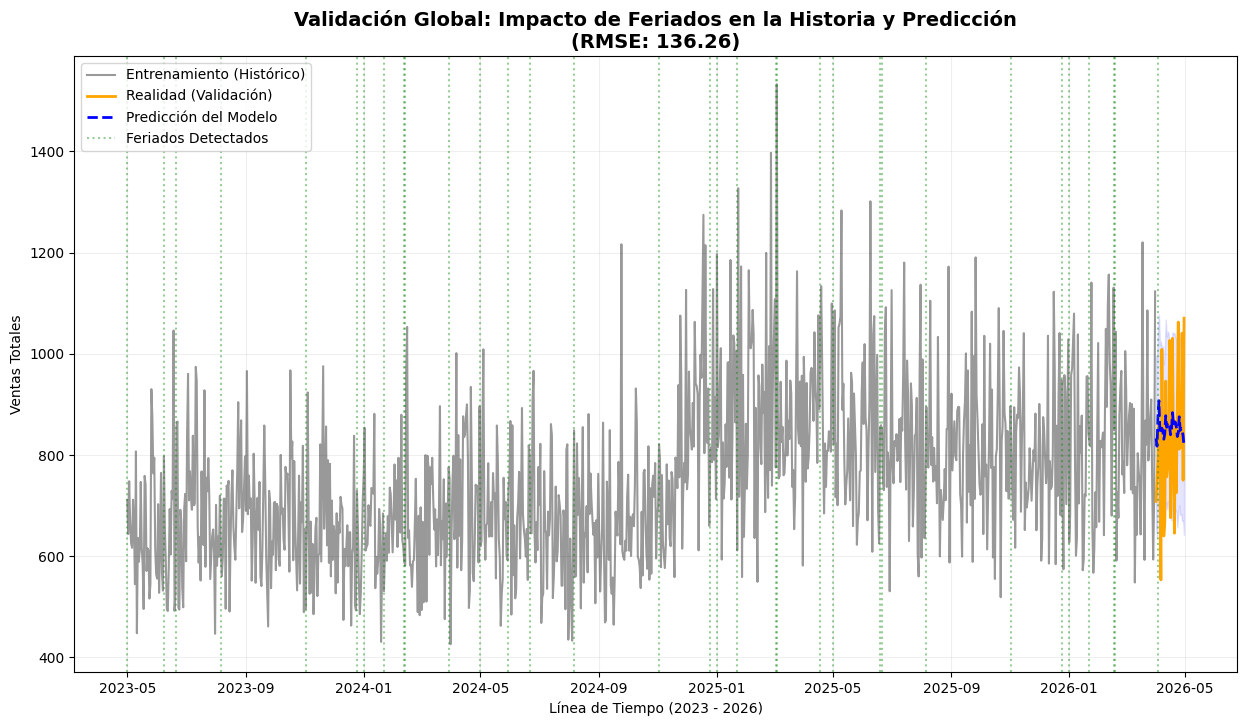

In [ ]:
# Visualización de la Validación Total con todos los feriados detectados
plt.figure(figsize=(15, 8))

# 1. Graficamos los datos reales (Train y Test)
plt.plot(train['ds'], train['y'], label='Entrenamiento (Histórico)', color='black', alpha=0.4)
plt.plot(test['ds'], test['y'], label='Realidad (Validación)', color='orange', linewidth=2)

# 2. Predicción del modelo
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Predicción del Modelo', color='blue', linestyle='--', linewidth=2)

# 3. Sombreado de confianza
plt.fill_between(forecast_test['ds'], forecast_test['yhat_lower'], forecast_test['yhat_upper'], color='blue', alpha=0.1)

# 4. MARCAR TODOS LOS FERIADOS
# Filtramos la lista de feriados para que solo muestre los que existen en el rango del data
mask_total = (feriados_bolivia['ds'] >= train['ds'].min()) & (feriados_bolivia['ds'] <= test['ds'].max())
feriados_visibles = feriados_bolivia[mask_total]

for i, holiday_date in enumerate(feriados_visibles['ds']):
    # Añadimos la etiqueta solo al primer feriado para no llenar la leyenda de "Feriado"
    label_feriado = "Feriados Detectados" if i == 0 else ""
    plt.axvline(x=holiday_date, color='green', linestyle=':', alpha=0.4, label=label_feriado)

plt.title(f'Validación Global: Impacto de Feriados en la Historia y Predicción\n(RMSE: {rmse:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Línea de Tiempo (2023 - 2026)')
plt.ylabel('Ventas Totales')

# Leyenda organizada
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.2)

plt.show()

Línea Negra: Representa el historial de ventas que el modelo analizó para aprender los patrones del negocio.

Línea Naranja: Es la realidad de los últimos 30 días (el "examen").

Línea Azul Punteada: Es la predicción que hizo la IA para ese mismo periodo.

Líneas Verdes Punteadas (Feriados): Marcan los eventos festivos en toda la línea de tiempo. Permiten observar cómo el modelo ajusta su predicción cuando detecta un feriado, intentando replicar las caídas o subidas históricas.

RMSE (136.26): Es nuestro indicador de precisión. Una diferencia de 136 Bs en un negocio que mueve miles es un margen de error muy bajo, lo que valida la confianza en el modelo.

El hecho de que la línea azul siga la tendencia de la naranja, especialmente cerca de las líneas verdes, confirma que el modelo no solo entiende los días de la semana, sino también el calendario social de Bolivia. Esto reduce el riesgo de falsas alarmas por bajas ventas en días festivos.

#PASO 6.1: Validación visual (Realidad vs. Predicción)
Una vez determinado el error matemático (RMSE), realizamos una inspección visual quirúrgica para confirmar la fiabilidad del modelo. En esta gráfica nos enfocamos exclusivamente en los últimos 30 días registrados, enfrentando los datos reales (puntos negros) contra las estimaciones de la Inteligencia Artificial (línea azul).

El valor agregado de este análisis es la integración de los feriados (líneas verdes). El objetivo es verificar que el modelo no solo replique el ritmo de ventas diario, sino que sea capaz de ajustar sus expectativas ante eventos del calendario boliviano, demostrando que la predicción es robusta y consciente del contexto local.

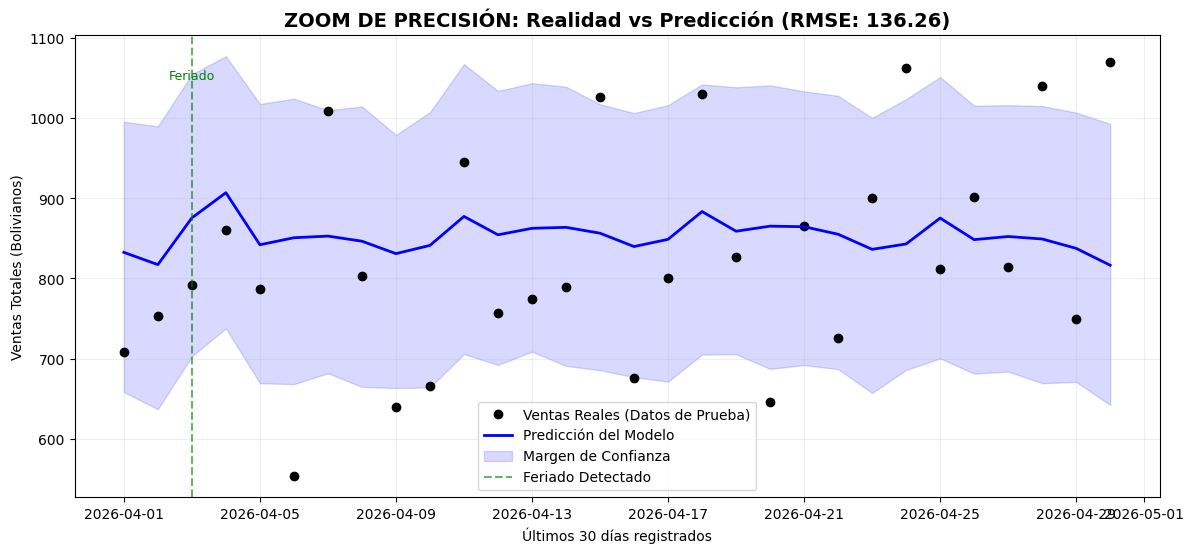

In [ ]:
# CÓDIGO: Gráfico comparativo de Validación (Zoom en el último mes con Feriados)
plt.figure(figsize=(14, 6))

# 1. Graficamos la realidad y la predicción
plt.plot(test['ds'], test['y'], 'ko', label='Ventas Reales (Datos de Prueba)', markersize=6)
plt.plot(forecast_test['ds'], forecast_test['yhat'], color='blue', label='Predicción del Modelo', linewidth=2)

# 2. Sombreado de confianza
plt.fill_between(forecast_test['ds'], forecast_test['yhat_lower'], forecast_test['yhat_upper'], color='blue', alpha=0.15, label='Margen de Confianza')

# 3. Resaltar Feriados dentro del Zoom (Últimos 30 días)
mask_zoom = (feriados_bolivia['ds'] >= test['ds'].min()) & (feriados_bolivia['ds'] <= test['ds'].max())
feriados_zoom = feriados_bolivia[mask_zoom]

for i, holiday_date in enumerate(feriados_zoom['ds']):
    label_f = "Feriado Detectado" if i == 0 else ""
    plt.axvline(x=holiday_date, color='green', linestyle='--', alpha=0.6, label=label_f)
    # Añadimos un pequeño texto indicativo arriba
    plt.text(holiday_date, plt.gca().get_ylim()[1]*0.95, 'Feriado', color='green', fontsize=9, rotation=0, ha='center')

plt.title(f'ZOOM DE PRECISIÓN: Realidad vs Predicción (RMSE: {rmse:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Últimos 30 días registrados')
plt.ylabel('Ventas Totales (Bolivianos)')

# Limpiamos la leyenda para que no repita "Feriado Detectado"
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='best')

plt.grid(True, alpha=0.2)
plt.show()

#PASO 6.2: Descomposición y Análisis de Componentes del Modelo

Para entender cómo la Inteligencia Artificial llega a sus conclusiones, desglosamos el pronóstico en sus cuatro pilares fundamentales: la tendencia a largo plazo, el impacto de los feriados, el comportamiento semanal y la estacionalidad anual. Este análisis permite identificar no solo cuánto se venderá, sino por qué ocurren las variaciones en los ingresos.

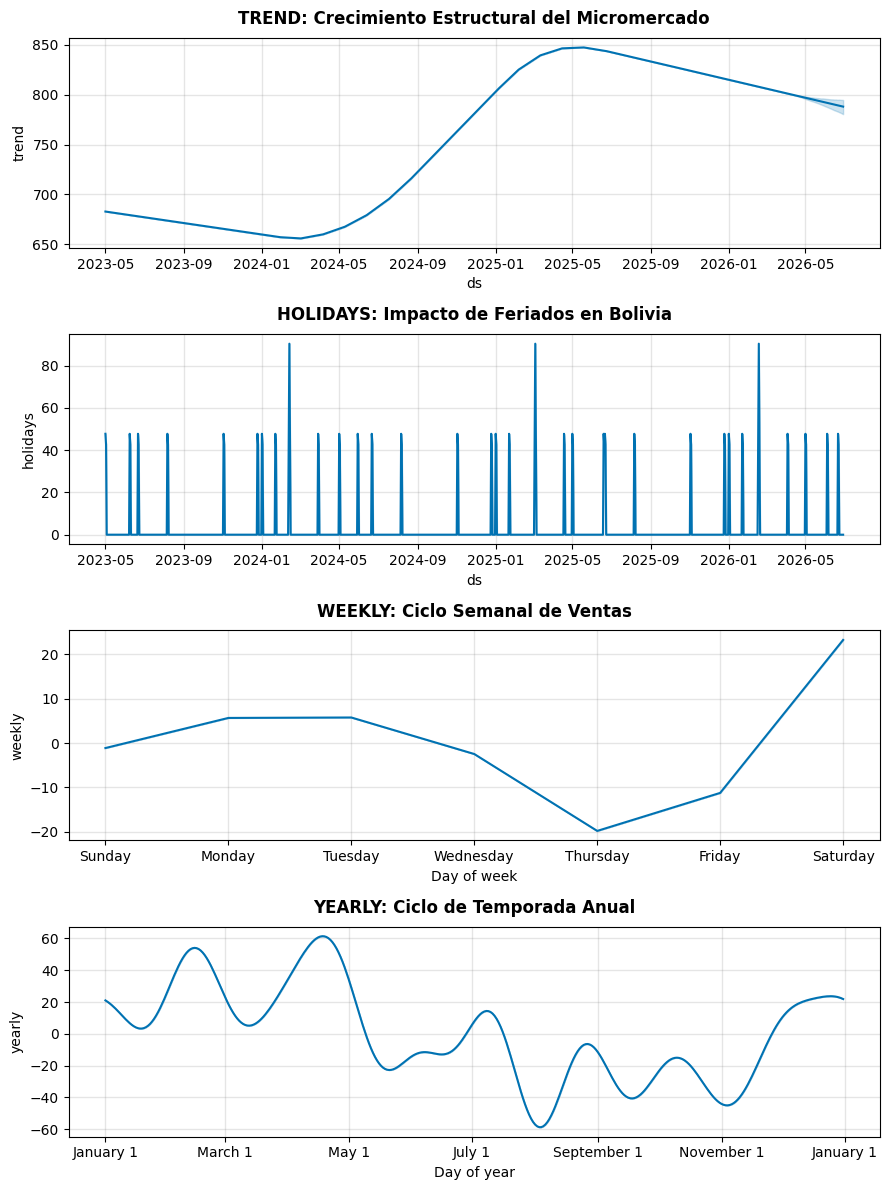

In [ ]:
# 1. Crear el horizonte de predicción (90 días hacia adelante usando tu modelo 'm')
future_final = m.make_future_dataframe(periods=90)

# 2. Generar la predicción usando tu modelo entrenado 'm'
forecast_final = m.predict(future_final)

# 3. Graficar los componentes desglosados (Tendencia, Feriados, Semanal, Anual)
fig_comp = m.plot_components(forecast_final)

# 4. Personalización de títulos adaptados a las subtramas generadas
axes = fig_comp.get_axes()

# Validamos cuántos componentes graficó Prophet para evitar errores de índice
if len(axes) >= 4:
    axes[0].set_title("TREND: Crecimiento Estructural del Micromercado", fontsize=12, fontweight='bold', pad=10)
    axes[1].set_title("HOLIDAYS: Impacto de Feriados en Bolivia", fontsize=12, fontweight='bold', pad=10)
    axes[2].set_title("WEEKLY: Ciclo Semanal de Ventas", fontsize=12, fontweight='bold', pad=10)
    axes[3].set_title("YEARLY: Ciclo de Temporada Anual", fontsize=12, fontweight='bold', pad=10)
else:
    # Ajuste dinámico por si genera menos componentes visuales
    for idx, ax in enumerate(axes):
        ax.set_title(f"Componente Temporal {idx + 1}", fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

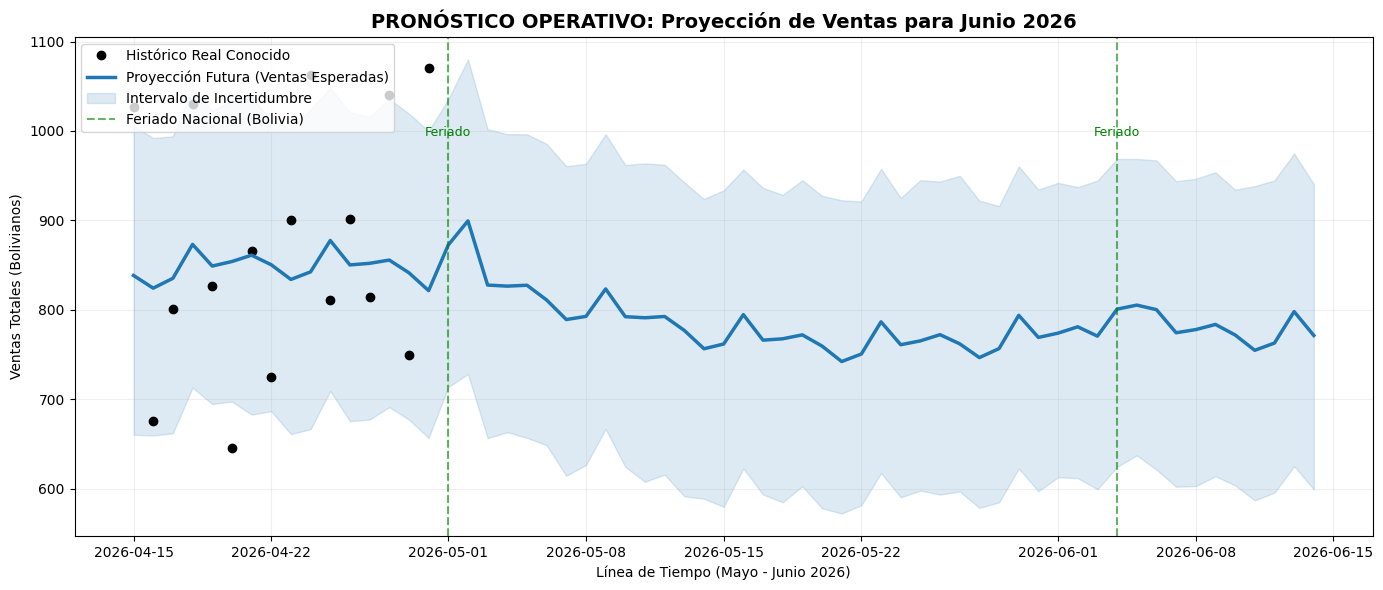

In [ ]:
# 1. Entrenamos el modelo definitivo con ABSOLUTAMENTE TODOS los datos (df_input completo)
m_futuro = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=feriados_bolivia
)
m_futuro.fit(df_input)

# 2. Creamos el horizonte de predicción hacia el futuro
future_dates = m_futuro.make_future_dataframe(periods=45, freq='D')

# 3. Dejamos que Prophet prediga el futuro
forecast_futuro = m_futuro.predict(future_dates)

# 4. Graficamos el resultado enfocándonos en el horizonte futuro (Junio)
plt.figure(figsize=(14, 6))

# Filtramos el histórico y la predicción para ver el cierre del histórico y el nuevo mes de Junio
fecha_limite_vista = df_input['ds'].max() - pd.Timedelta(days=15)
forecast_vista = forecast_futuro[forecast_futuro['ds'] >= fecha_limite_vista]
df_input_vista = df_input[df_input['ds'] >= fecha_limite_vista]

# Graficamos datos reales históricos (puntos negros)
plt.plot(df_input_vista['ds'], df_input_vista['y'], 'ko', label='Histórico Real Conocido', markersize=6)

# Graficamos la predicción que se extiende hacia el futuro (Línea azul)
plt.plot(forecast_vista['ds'], forecast_vista['yhat'], color='#1f77b4', label='Proyección Futura (Ventas Esperadas)', linewidth=2.5)
plt.fill_between(forecast_vista['ds'], forecast_vista['yhat_lower'], forecast_vista['yhat_upper'], color='#1f77b4', alpha=0.15, label='Intervalo de Incertidumbre')

# Resaltar el feriado de Corpus Christi (18 o 19 de Junio según el año) o Año Nuevo Andino (21 de Junio)
mask_feriados_junio = (feriados_bolivia['ds'] >= fecha_limite_vista) & (feriados_bolivia['ds'] <= forecast_vista['ds'].max())
feriados_junio = feriados_bolivia[mask_feriados_junio]

for i, holiday_date in enumerate(feriados_junio['ds']):
    label_f = "Feriado Nacional (Bolivia)" if i == 0 else ""
    plt.axvline(x=holiday_date, color='green', linestyle='--', alpha=0.6, label=label_f)
    plt.text(holiday_date, plt.gca().get_ylim()[1]*0.90, 'Feriado', color='green', fontsize=9, ha='center')

# Formateo estético del gráfico
plt.title('PRONÓSTICO OPERATIVO: Proyección de Ventas para Junio 2026', fontsize=14, fontweight='bold')
plt.xlabel('Línea de Tiempo (Mayo - Junio 2026)')
plt.ylabel('Ventas Totales (Bolivianos)')
plt.grid(True, alpha=0.2)

# Ajustar leyenda
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.tight_layout()
plt.show()

"Análisis detallado de eventos especiales (Feriados)".

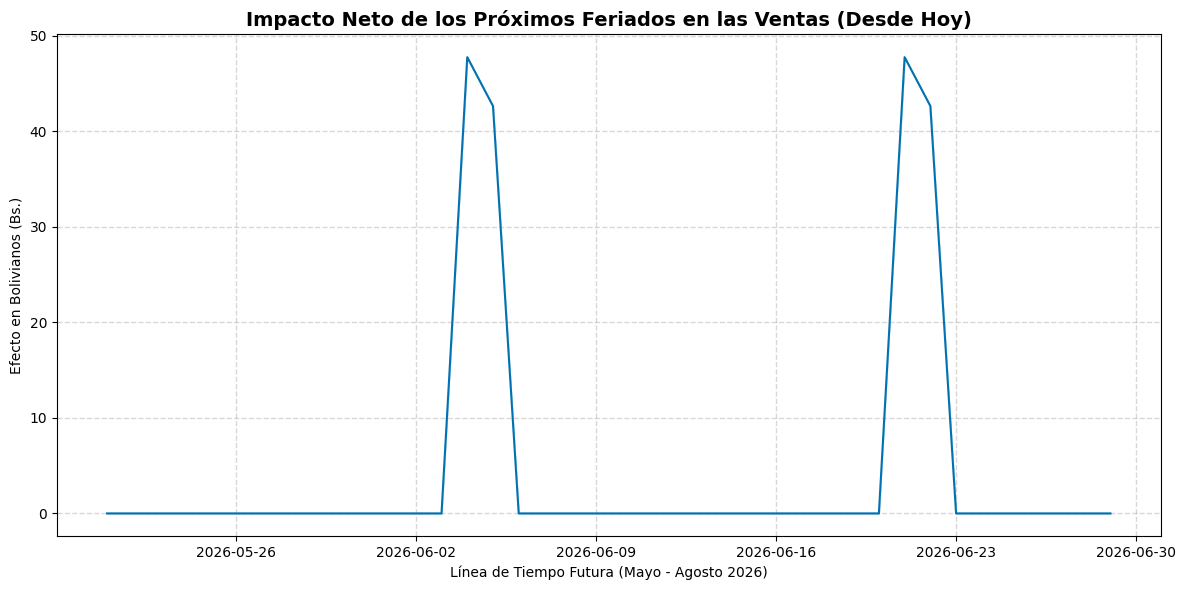


🔮 PRONÓSTICO DE IMPACTO COMERCIAL (DESDE HOY 2026-05-21)
📌 El Jueves 2026-06-04 la IA prevé un AUMENTO 📈 de 47.74 Bs. en cajas.
📌 El Viernes 2026-06-05 la IA prevé un AUMENTO 📈 de 42.63 Bs. en cajas.
📌 El Domingo 2026-06-21 la IA prevé un AUMENTO 📈 de 47.74 Bs. en cajas.
📌 El Lunes 2026-06-22 la IA prevé un AUMENTO 📈 de 42.63 Bs. en cajas.


In [ ]:
from prophet.plot import plot_forecast_component
# 1. Definimos la fecha de hoy de forma estricta (Mayo 2026)
fecha_hoy = pd.to_datetime('2026-05-21')

# 2. Generar un horizonte futuro largo (90 días) para cubrir los próximos meses
future_real = m.make_future_dataframe(periods=90, freq='D')
forecast_real = m.predict(future_real)

# 3. FILTRADO CRÍTICO: Seleccionamos solo las predicciones desde HOY en adelante
forecast_futuro_real = forecast_real[forecast_real['ds'] >= fecha_hoy].copy()

fig, ax = plt.subplots(figsize=(12, 6))

# Graficamos el componente de feriados usando los datos filtrados del futuro
plot_forecast_component(m, forecast_futuro_real, 'holidays', ax=ax)

plt.title('Impacto Neto de los Próximos Feriados en las Ventas (Desde Hoy)', fontsize=14, fontweight='bold')
plt.ylabel('Efecto en Bolivianos (Bs.)')
plt.xlabel('Línea de Tiempo Futura (Mayo - Agosto 2026)')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Filtramos los días donde el impacto de feriados no sea cero
proximos_feriados = forecast_futuro_real[forecast_futuro_real['holidays'] != 0].head(10)

print("\n====================================================================")
print(f"🔮 PRONÓSTICO DE IMPACTO COMERCIAL (DESDE HOY {fecha_hoy.strftime('%Y-%m-%d')})")
print("====================================================================")

if not proximos_feriados.empty:
    for index, row in proximos_feriados.iterrows():
        tipo = "CAÍDA 📉" if row['holidays'] < 0 else "AUMENTO 📈"
        dia_semana = row['ds'].day_name()

        # Diccionario rápido para mostrar el día de la semana en el reporte
        dias_es = {'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
                   'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'}
        nom_dia = dias_es.get(dia_semana, '')

        print(f"📌 El {nom_dia} {row['ds'].date()} la IA prevé un {tipo} de {abs(row['holidays']):.2f} Bs. en cajas.")
else:
    print("No se detectan feriados nacionales en los próximos 90 días dentro del horizonte.")
print("====================================================================")

#PASO 7 :  Analítica avanzada orientada a la rentabilidad del negocio

## Opción 1: Predicción de Ganancia Neta Global a 90 días (Enfoque Financiero)
Explicación Conceptual:
Hasta el momento, el modelo predictivo macro se ha enfocado en proyectar las ventas brutas (todo el flujo de caja que ingresa al micromercado). Sin embargo, un alto volumen de ventas no siempre se traduce de forma directa en éxito financiero, ya que existen productos de alta rotación pero con márgenes de ganancia mínimos.

En esta sección, realizamos una reingeniería de variables en nuestro dataset histórico para aislar la Ganancia Neta Real de la tienda. Al aplicar el algoritmo estadístico de Prophet sobre el histórico de ganancias puras, la Inteligencia Artificial proyectará la rentabilidad real libre de costos para los próximos 90 días. Esto le permite a la administración del Micromercado Doña Eva conocer con certeza científica el capital neto del que dispondrá a mediano plazo (lo que resta de mayo, junio, julio y parte de agosto de 2026) para reinversión, pago de obligaciones con proveedores o utilidades líquidas acumuladas.

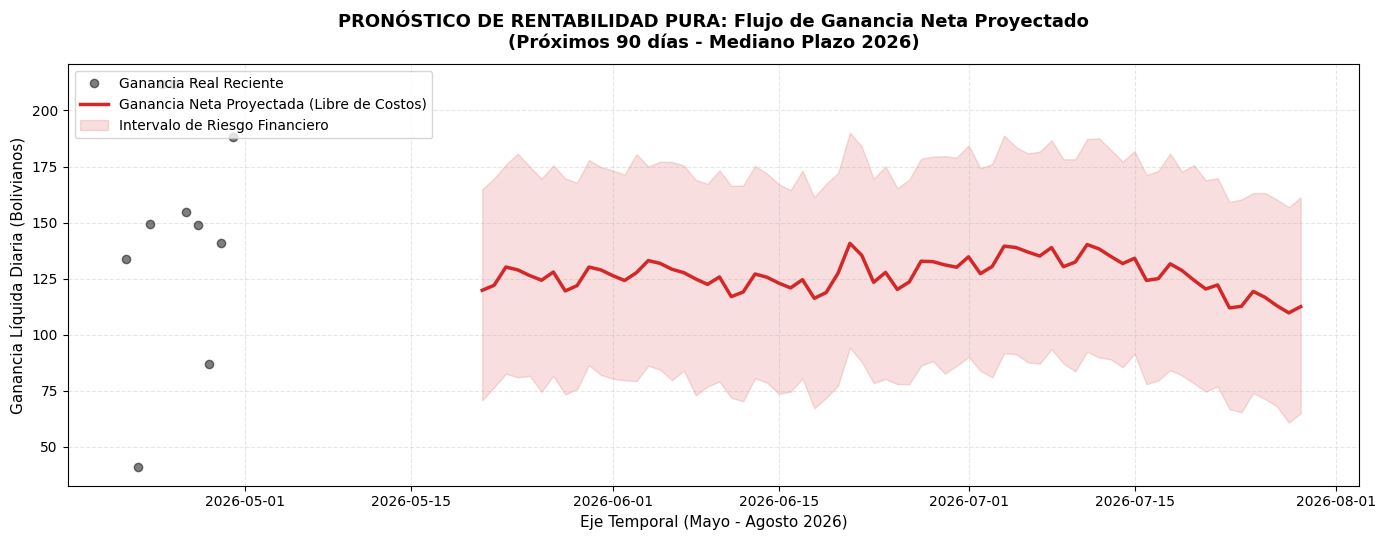


💵 REPORTE EJECUTIVO: AUDITORÍA DE RENTABILIDAD PROYECTADA (90 DÍAS)
💰 GANANCIA NETA TOTAL ACUMULADA ESPERADA (90 días): 8,867.67 Bs.
📈 GANANCIA NETA PROMEDIO DIARIA DICTAMINADA:        126.68 Bs./día
--------------------------------------------------------------------
🚀 PICO MÁXIMO DE GANANCIA LÍQUIDA EN UN DÍA:
   Fecha: 2026-06-21 | Monto Esperado: 140.76 Bs.
   (Efecto impulsado por: Estacionalidad semanal y matriz de feriados)
--------------------------------------------------------------------
📉 PISO MÍNIMO DE GANANCIA LÍQUIDA EN UN DÍA:
   Fecha: 2026-07-28 | Monto Esperado: 109.77 Bs.
   (Alerta comercial: Planificar estrategias de promoción para mitigar esta jornada)


In [ ]:
# 1. Asegurar el formato numérico correcto de la ganancia neta en el dataframe base
df['Ganancia_Neta'] = pd.to_numeric(df['Ganancia_Neta'].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)

# 2. Agrupar las ganancias netas de manera diaria para estructurar el dataset de Prophet
df_ganancia_diaria = df.groupby('Fecha')['Ganancia_Neta'].sum().reset_index()
df_ganancia_diaria.columns = ['ds', 'y']

# Asegurar que la columna 'ds' esté en formato datetime
df_ganancia_diaria['ds'] = pd.to_datetime(df_ganancia_diaria['ds'])

# 3. Instanciar y entrenar el modelo Prophet exclusivo para Ganancias Netas
m_ganancias = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=feriados_bolivia
)
m_ganancias.fit(df_ganancia_diaria)

# 4. Crear el horizonte futuro de 90 días y generar la predicción
future_90_finances = m_ganancias.make_future_dataframe(periods=90, freq='D')
forecast_ganancias = m_ganancias.predict(future_90_finances)

# 5. Filtrar los resultados para evaluar el futuro real a partir de hoy (21 de Mayo de 2026)
fecha_hoy = pd.to_datetime('2026-05-21')
proyeccion_ganancias_futuras = forecast_ganancias[forecast_ganancias['ds'] >= fecha_hoy].copy()

# ==============================================================================
# VISUALIZACIÓN GRÁFICA DEL FLUJO DE GANANCIAS NETAS (90 DÍAS)
# ==============================================================================
plt.figure(figsize=(14, 5.5))

# Histórico reciente de ganancias (últimos 30 días para contexto)
historico_ganancias_reciente = df_ganancia_diaria[df_ganancia_diaria['ds'] >= (fecha_hoy - pd.Timedelta(days=30))]
plt.plot(historico_ganancias_reciente['ds'], historico_ganancias_reciente['y'], 'ko', label='Ganancia Real Reciente', alpha=0.5)

# Curva de ganancias proyectadas hacia el futuro (90 días)
plt.plot(proyeccion_ganancias_futuras['ds'], proyeccion_ganancias_futuras['yhat'], color='#d62728', label='Ganancia Neta Proyectada (Libre de Costos)', linewidth=2.5)
plt.fill_between(proyeccion_ganancias_futuras['ds'], proyeccion_ganancias_futuras['yhat_lower'], proyeccion_ganancias_futuras['yhat_upper'], color='#d62728', alpha=0.15, label='Intervalo de Riesgo Financiero')

plt.title('PRONÓSTICO DE RENTABILIDAD PURA: Flujo de Ganancia Neta Proyectado\n(Próximos 90 días - Mediano Plazo 2026)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Eje Temporal (Mayo - Agosto 2026)', fontsize=11)
plt.ylabel('Ganancia Líquida Diaria (Bolivianos)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# ==============================================================================
# REPORTE ESCRITO DE RESULTADOS
# ==============================================================================
ganancia_acumulada_90 = proyeccion_ganancias_futuras['yhat'].sum()
ganancia_promedio_diaria = proyeccion_ganancias_futuras['yhat'].mean()
pico_ganancia_fila = proyeccion_ganancias_futuras.loc[proyeccion_ganancias_futuras['yhat'].idxmax()]
piso_ganancia_fila = proyeccion_ganancias_futuras.loc[proyeccion_ganancias_futuras['yhat'].idxmin()]

print("\n====================================================================")
print("💵 REPORTE EJECUTIVO: AUDITORÍA DE RENTABILIDAD PROYECTADA (90 DÍAS)")
print("====================================================================")
print(f"💰 GANANCIA NETA TOTAL ACUMULADA ESPERADA (90 días): {ganancia_acumulada_90:,.2f} Bs.")
print(f"📈 GANANCIA NETA PROMEDIO DIARIA DICTAMINADA:        {ganancia_promedio_diaria:,.2f} Bs./día")
print("--------------------------------------------------------------------")
print(f"🚀 PICO MÁXIMO DE GANANCIA LÍQUIDA EN UN DÍA:")
print(f"   Fecha: {pico_ganancia_fila['ds'].strftime('%Y-%m-%d')} | Monto Esperado: {pico_ganancia_fila['yhat']:,.2f} Bs.")
print(f"   (Efecto impulsado por: Estacionalidad semanal y matriz de feriados)")
print("--------------------------------------------------------------------")
print(f"📉 PISO MÍNIMO DE GANANCIA LÍQUIDA EN UN DÍA:")
print(f"   Fecha: {piso_ganancia_fila['ds'].strftime('%Y-%m-%d')} | Monto Esperado: {piso_ganancia_fila['yhat']:,.2f} Bs.")
print(f"   (Alerta comercial: Planificar estrategias de promoción para mitigar esta jornada)")
print("====================================================================")

## Opción 2: Predicción de Demanda por Categorías Críticas (Enfoque de Inventario)
Explicación Conceptual:
Uno de los desafíos operativos más complejos en la gestión de un micromercado es el control de inventarios. El desabastecimiento de productos estrella provoca pérdidas directas de ventas, mientras que el exceso de stock inmoviliza capital de trabajo y eleva el riesgo de pérdidas por vencimiento. Para mitigar esto, transitamos de un análisis macro a un modelo de optimización logística.

En esta sección, agrupamos el histórico de ventas en las Categorías Críticas del negocio. Al entrenar algoritmos de Prophet independientes para cada categoría a un horizonte de 90 días, la Inteligencia Artificial proyecta el volumen de demanda esperado semana a semana. Esta información permite a la administración del Micromercado Doña Eva automatizar su cadena de suministro, negociar de forma anticipada con proveedores clave y garantizar un flujo de caja eficiente alineado con los ciclos reales de consumo.

📦 CATEGORÍAS CRÍTICAS IDENTIFICADAS PARA OPTIMIZACIÓN DE INVENTARIO
1. Refrescos
2. Tarjetas
3. Alimentos del hogar


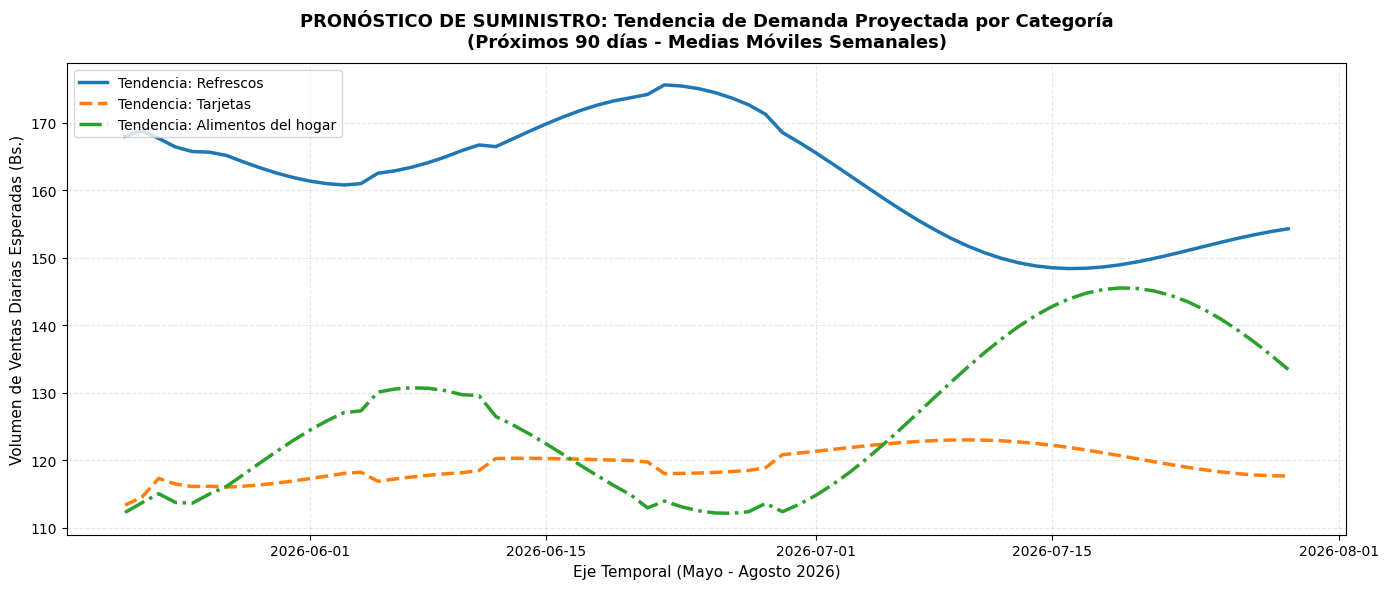


📋 REPORTE LOGÍSTICO: PLANIFICACIÓN DE REABASTECIMIENTO (90 DÍAS)
🗂️ CATEGORÍA: REFRESCOS
   ▪️ Demanda Total Acumulada Proyectada: 11,281.51 Bs.
   ▪️ Cuota de Abastecimiento Diario Sugerido: 161.16 Bs./día
   ▪️ Pico de Máxima Demanda: 2026-06-22 (181.74 Bs.)
--------------------------------------------------------------------
🗂️ CATEGORÍA: TARJETAS
   ▪️ Demanda Total Acumulada Proyectada: 8,356.27 Bs.
   ▪️ Cuota de Abastecimiento Diario Sugerido: 119.38 Bs./día
   ▪️ Pico de Máxima Demanda: 2026-07-04 (129.98 Bs.)
--------------------------------------------------------------------
🗂️ CATEGORÍA: ALIMENTOS DEL HOGAR
   ▪️ Demanda Total Acumulada Proyectada: 8,884.72 Bs.
   ▪️ Cuota de Abastecimiento Diario Sugerido: 126.92 Bs./día
   ▪️ Pico de Máxima Demanda: 2026-07-18 (149.25 Bs.)
--------------------------------------------------------------------


In [ ]:
# 1. Asegurar el formato numérico correcto de las ventas en el dataframe base
df['Venta_Total'] = pd.to_numeric(df['Venta_Total'].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)

# 2. Identificar las 3 categorías que generan más movimiento comercial
top_categorias = df.groupby('Categoria')['Venta_Total'].sum().nlargest(3).index.tolist()

print("====================================================================")
print("📦 CATEGORÍAS CRÍTICAS IDENTIFICADAS PARA OPTIMIZACIÓN DE INVENTARIO")
print("====================================================================")
for i, cat in enumerate(top_categorias, 1):
    print(f"{i}. {cat}")
print("====================================================================")

# 3. Diccionario para almacenar las proyecciones futuras de cada categoría
proyecciones_categorias = {}
fecha_hoy = pd.to_datetime('2026-05-21')

# 4. Iterar y entrenar un modelo Prophet exclusivo por cada categoría líder
for cat in top_categorias:
    # Filtrar y agrupar de forma diaria para la categoría actual
    df_cat = df[df['Categoria'] == cat].groupby('Fecha')['Venta_Total'].sum().reset_index()
    df_cat.columns = ['ds', 'y']
    df_cat['ds'] = pd.to_datetime(df_cat['ds'])

    # Instanciar y entrenar el modelo incorporando los feriados de Bolivia
    m_cat = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        holidays=feriados_bolivia
    )
    m_cat.fit(df_cat)

    # Crear horizonte de 90 días y predecir
    future_cat = m_cat.make_future_dataframe(periods=90, freq='D')
    forecast_cat = m_cat.predict(future_cat)

    # Filtrar desde hoy hacia el futuro y guardar
    proyecciones_categorias[cat] = forecast_cat[forecast_cat['ds'] >= fecha_hoy].copy()

# ==============================================================================
# VISUALIZACIÓN GRÁFICA DE LA DEMANDA FUTURA POR CATEGORÍA
# ==============================================================================
plt.figure(figsize=(14, 6))

estilos = ['-', '--', '-.']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, cat in enumerate(top_categorias):
    df_plot = proyecciones_categorias[cat]
    # Usamos una media móvil de 7 días (rolling) para suavizar el gráfico y ver la tendencia limpia
    ventas_suavizadas = df_plot['yhat'].rolling(window=7, min_periods=1).mean()

    plt.plot(df_plot['ds'], ventas_suavizadas, label=f'Tendencia: {cat}',
             color=colores[idx], linestyle=estilos[idx], linewidth=2.5)

plt.title('PRONÓSTICO DE SUMINISTRO: Tendencia de Demanda Proyectada por Categoría\n(Próximos 90 días - Medias Móviles Semanales)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Eje Temporal (Mayo - Agosto 2026)', fontsize=11)
plt.ylabel('Volumen de Ventas Diarias Esperadas (Bs.)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# ==============================================================================
# REPORTE ESCRITO DE RESULTADOS
# ==============================================================================
print("\n====================================================================")
print("📋 REPORTE LOGÍSTICO: PLANIFICACIÓN DE REABASTECIMIENTO (90 DÍAS)")
print("====================================================================")

for cat in top_categorias:
    df_fut = proyecciones_categorias[cat]
    total_90 = df_fut['yhat'].sum()
    promedio_diario = df_fut['yhat'].mean()
    pico_fila = df_fut.loc[df_fut['yhat'].idxmax()]

    print(f"🗂️ CATEGORÍA: {cat.upper()}")
    print(f"   ▪️ Demanda Total Acumulada Proyectada: {total_90:,.2f} Bs.")
    print(f"   ▪️ Cuota de Abastecimiento Diario Sugerido: {promedio_diario:,.2f} Bs./día")
    print(f"   ▪️ Pico de Máxima Demanda: {pico_fila['ds'].strftime('%Y-%m-%d')} ({pico_fila['yhat']:,.2f} Bs.)")
    print("--------------------------------------------------------------------")
print("====================================================================")

## Opción 3: Predicción de Ventas por Método de Pago (Efectivo vs. QR)
Explicación Conceptual:
La digitalización transaccional mediante códigos QR ha transformado la velocidad de cobro en los canales minoristas de Bolivia, reduciendo la fricción en ventas de tickets altos. Sin embargo, para un micromercado de barrio, mantener un equilibrio de liquidez es crucial. Los repartidores y proveedores de industrias clave (como lácteos, bebidas gaseosas o abarrotes) exigen de forma mayoritaria la liquidación de facturas en efectivo físico al momento de la entrega.

En esta sección, separamos los flujos históricos de caja basándonos en la variable del Método de Pago. Al entrenar dos modelos Prophet en paralelo con un horizonte de 90 días, la Inteligencia Artificial proyecta el comportamiento y la disponibilidad de caja física (Efectivo) frente a la caja bancaria digital (QR). Este análisis otorga una ventaja estratégica indispensable para el Micromercado Doña Eva, permitiendo planificar si los ingresos semanales en efectivo serán suficientes para cubrir las compras operativas cotidianas o si se requerirá programar retiros bancarios anticipados para evitar la parálisis del suministro.

💳 CANALES DE LIQUIDEZ IDENTIFICADOS
1. Canal: Efectivo
2. Canal: QR


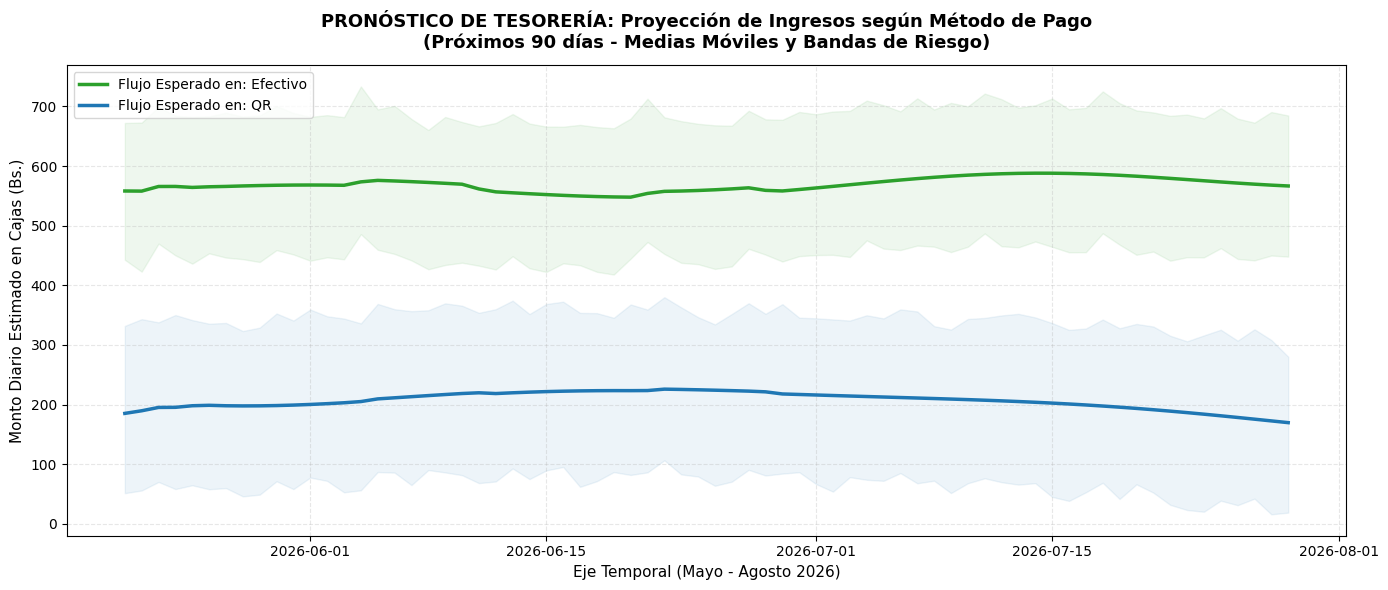


💵 REPORTE DE LIQUIDEZ: BALANCE DE ENTRADAS DE CAJA (90 DÍAS)
💰 MEDIO DE COBRO: EFECTIVO
   ▪️ Capital Acumulado Esperado (90 días): 39,829.05 Bs.
   ▪️ Inyección Diaria Promedio en este canal: 568.99 Bs./día
   ▪️ Participación Proyectada en el Mix de Caja: 73.47%
--------------------------------------------------------------------
💰 MEDIO DE COBRO: QR
   ▪️ Capital Acumulado Esperado (90 días): 14,381.36 Bs.
   ▪️ Inyección Diaria Promedio en este canal: 205.45 Bs./día
   ▪️ Participación Proyectada en el Mix de Caja: 26.53%
--------------------------------------------------------------------


In [ ]:
# 1. Asegurar el formato numérico correcto de las ventas en el dataframe base
df['Venta_Total'] = pd.to_numeric(df['Venta_Total'].astype(str).str.replace(',', '.'), errors='coerce').fillna(0)

# 2. Identificar los métodos de pago presentes en los datos (ej. Efectivo, QR)
# Forzamos a string para evitar errores y filtramos nulos
df['Metodo_Pago'] = df['Metodo_Pago'].astype(str).str.strip()
metodos_validos = [m for m in df['Metodo_Pago'].unique() if m not in ['nan', '', 'None']]

print("====================================================================")
print("💳 CANALES DE LIQUIDEZ IDENTIFICADOS")
print("====================================================================")
for i, met in enumerate(metodos_validos, 1):
    print(f"{i}. Canal: {met}")
print("====================================================================")

# 3. Diccionario para almacenar las predicciones futuras de cada método de pago
proyecciones_pagos = {}
fecha_hoy = pd.to_datetime('2026-05-21')

# 4. Entrenar modelos Prophet independientes para cada canal transaccional
for met in metodos_validos:
    # Filtrar y agrupar de forma diaria para el método de pago actual
    df_met = df[df['Metodo_Pago'] == met].groupby('Fecha')['Venta_Total'].sum().reset_index()
    df_met.columns = ['ds', 'y']
    df_met['ds'] = pd.to_datetime(df_met['ds'])

    # Validamos que el canal tenga suficientes datos históricos para entrenar
    if len(df_met) > 10:
        m_met = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            holidays=feriados_bolivia
        )
        m_met.fit(df_met)

        # Crear horizonte de 90 días y predecir
        future_met = m_met.make_future_dataframe(periods=90, freq='D')
        forecast_met = m_met.predict(future_met)

        # Filtrar desde hoy hacia el futuro y guardar
        proyecciones_pagos[met] = forecast_met[forecast_met['ds'] >= fecha_hoy].copy()

# ==============================================================================
# VISUALIZACIÓN GRÁFICA DE LA DISPONIBILIDAD DE CAJA FUTURA
# ==============================================================================
plt.figure(figsize=(14, 6))

colores_pago = {'Efectivo': '#2ca02c', 'QR': '#1f77b4', 'Tarjeta': '#7f7f7f'}

for met in proyecciones_pagos.keys():
    df_plot = proyecciones_pagos[met]
    # Suavizado de 7 días para identificar el comportamiento estructural del flujo de caja
    flujo_suavizado = df_plot['yhat'].rolling(window=7, min_periods=1).mean()

    color = colores_pago.get(met, '#9467bd')
    plt.plot(df_plot['ds'], flujo_suavizado, label=f'Flujo Esperado en: {met}',
             color=color, linewidth=2.5)
    plt.fill_between(df_plot['ds'], df_plot['yhat_lower'], df_plot['yhat_upper'],
                     color=color, alpha=0.08)

plt.title('PRONÓSTICO DE TESORERÍA: Proyección de Ingresos según Método de Pago\n(Próximos 90 días - Medias Móviles y Bandas de Riesgo)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Eje Temporal (Mayo - Agosto 2026)', fontsize=11)
plt.ylabel('Monto Diario Estimado en Cajas (Bs.)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# ==============================================================================
# REPORTE ESCRITO DE RESULTADOS (IMPRESIÓN EN CONSOLA)
# ==============================================================================
print("\n====================================================================")
print("💵 REPORTE DE LIQUIDEZ: BALANCE DE ENTRADAS DE CAJA (90 DÍAS)")
print("====================================================================")

# Calcular total consolidado para sacar porcentajes de participación futuros
gran_total_futuro = sum([df_f['yhat'].sum() for df_f in proyecciones_pagos.values()])

for met in proyecciones_pagos.keys():
    df_fut = proyecciones_pagos[met]
    total_canal = df_fut['yhat'].sum()
    promedio_canal = df_fut['yhat'].mean()
    participacion = (total_canal / gran_total_futuro) * 100 if gran_total_futuro > 0 else 0

    print(f"💰 MEDIO DE COBRO: {met.upper()}")
    print(f"   ▪️ Capital Acumulado Esperado (90 días): {total_canal:,.2f} Bs.")
    print(f"   ▪️ Inyección Diaria Promedio en este canal: {promedio_canal:,.2f} Bs./día")
    print(f"   ▪️ Participación Proyectada en el Mix de Caja: {participacion:.2f}%")
    print("--------------------------------------------------------------------")
print("====================================================================")

## Opción 4: Predicción de "Días Críticos" de Baja Venta (Efecto Escudo Comercial)
Explicación Conceptual:
La rentabilidad de un negocio minorista no solo se maximiza potenciando las jornadas de alta transaccionalidad, sino también blindando la operación durante los ciclos de contracción de la demanda. En la dinámica comercial de un barrio, existen días específicos donde el flujo peatonal cae drásticamente debido a factores estacionales, de calendario o de comportamiento del consumidor local.

En esta sección, configuramos un Efecto Escudo utilizando las capacidades predictivas de Prophet a un horizonte de 90 días. El algoritmo analiza la serie temporal para identificar de manera automatizada aquellas jornadas donde las ventas proyectadas caen por debajo del umbral mínimo de equilibrio operativo del micromercado. Al geolocalizar estas fechas críticas de forma anticipada, la administración del Micromercado Doña Eva adquiere la capacidad de diseñar estrategias de mitigación proactivas —tales como promociones cruzadas, liquidación controlada de inventarios de baja rotación o reducción selectiva de costos operativos diarios—, transformando jornadas de pérdida latente en oportunidades de optimización controlada.

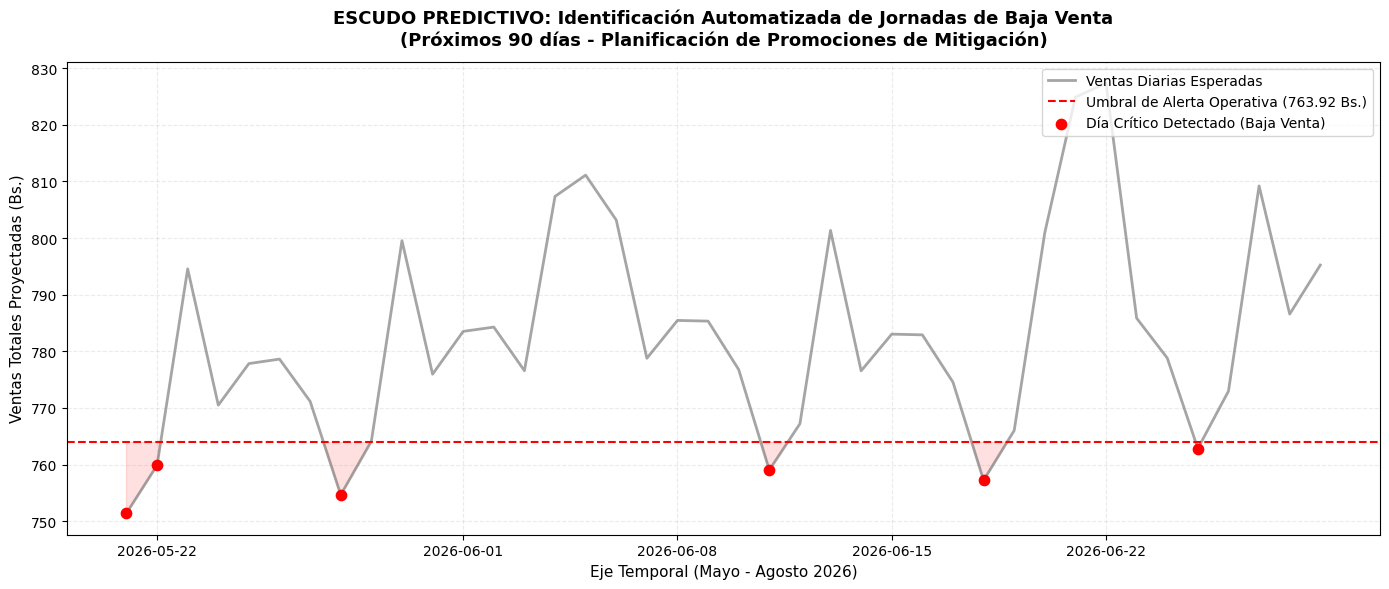


🚨 REPORT DE ALERTA TEMPRANA: PLAN DE CONTINGENCIA COMERCIAL
⚠️ Umbral de Alerta Estadística fijado en: 763.92 Bs.
⚠️ Cantidad de jornadas de baja venta identificadas en los próximos 90 días: 6 días.
--------------------------------------------------------------------
📋 TOP 5 FECHAS PRÓXIMAS MÁS CRÍTICAS QUE REQUIEREN ACCIÓN INMEDIATA:
   🛑 Jueves 2026-05-21 | Venta Estimada: 751.40 Bs. (Caída drástica)
   🛑 Jueves 2026-05-28 | Venta Estimada: 754.65 Bs. (Caída drástica)
   🛑 Jueves 2026-06-18 | Venta Estimada: 757.21 Bs. (Caída drástica)
   🛑 Jueves 2026-06-11 | Venta Estimada: 759.03 Bs. (Caída drástica)
   🛑 Viernes 2026-05-22 | Venta Estimada: 759.87 Bs. (Caída drástica)
--------------------------------------------------------------------
💡 ACCIONES MITIGANTES RECOMENDADAS PARA EL TRIBUNAL:
   1. Lanzar combos relámpago de productos de alta rotación (Coca-Cola + Snacks) en esas fechas.
   2. Ajustar el pedido de productos perecederos (pan, lácteos) el día anterior para evitar merma

In [ ]:
# ==============================================================================
# OPCIÓN 4: PREDICCIÓN DE DÍAS CRÍTICOS Y ALERTA DE BAJA DEMANDA (90 DÍAS)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraer la predicción macro de ventas que ya calculamos en 'forecast_real'
# Nos aseguramos de evaluar estrictamente los 90 días desde hoy (21 de Mayo de 2026)
fecha_hoy = pd.to_datetime('2026-05-21')
proyeccion_escudo = forecast_real[forecast_real['ds'] >= fecha_hoy].copy()

# 2. Establecer estadísticamente el "Umbral Crítico de Baja Venta"
# Definimos el umbral como el Percentil 15 de las ventas esperadas (los días más fríos del trimestre)
umbral_critico = proyeccion_escudo['yhat'].quantile(0.15)

# 3. Filtrar e identificar las fechas que caen por debajo de ese límite operativo
dias_criticos = proyeccion_escudo[proyeccion_escudo['yhat'] <= umbral_critico].copy()

# ==============================================================================
# VISUALIZACIÓN GRÁFICA DEL ESCUDO PREDICTIVO (ALERTAS COMERCIALES)
# ==============================================================================
plt.figure(figsize=(14, 6))

# Graficamos la línea continua de ventas proyectadas para el mediano plazo
plt.plot(proyeccion_escudo['ds'], proyeccion_escudo['yhat'], color='#7f7f7f', label='Ventas Diarias Esperadas', linewidth=2, alpha=0.7)

# Pintamos una línea discontinua roja que marca el límite del peligro financiero
plt.axhline(y=umbral_critico, color='red', linestyle='--', linewidth=1.5, label=f'Umbral de Alerta Operativa ({umbral_critico:.2f} Bs.)')

# Resaltamos con puntos rojos grandes y visibles los "Días Críticos" detectados por la IA
plt.scatter(dias_criticos['ds'], dias_criticos['yhat'], color='red', s=55, zorder=5, label='Día Crítico Detectado (Baja Venta)')

# Sombreado de la zona de riesgo
plt.fill_between(proyeccion_escudo['ds'], proyeccion_escudo['yhat'], umbral_critico,
                 where=(proyeccion_escudo['yhat'] <= umbral_critico), color='red', alpha=0.12, interpolate=True)

plt.title('ESCUDO PREDICTIVO: Identificación Automatizada de Jornadas de Baja Venta\n(Próximos 90 días - Planificación de Promociones de Mitigación)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Eje Temporal (Mayo - Agosto 2026)', fontsize=11)
plt.ylabel('Ventas Totales Proyectadas (Bs.)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.25)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

# ==============================================================================
# REPORTE ESCRITO DE ALERTAS TEMPRANAS (IMPRESIÓN EN CONSOLA)
# ==============================================================================
print("\n====================================================================")
print("🚨 REPORT DE ALERTA TEMPRANA: PLAN DE CONTINGENCIA COMERCIAL")
print("====================================================================")
print(f"⚠️ Umbral de Alerta Estadística fijado en: {umbral_critico:,.2f} Bs.")
print(f"⚠️ Cantidad de jornadas de baja venta identificadas en los próximos 90 días: {len(dias_criticos)} días.")
print("--------------------------------------------------------------------")
print("📋 TOP 5 FECHAS PRÓXIMAS MÁS CRÍTICAS QUE REQUIEREN ACCIÓN INMEDIATA:")

# Diccionario para mapear los días de la semana a español
dias_es = {'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
           'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'}

top_5_criticos = dias_criticos.nsmallest(5, 'yhat')

for idx, row in top_5_criticos.iterrows():
    nom_dia = dias_es.get(row['ds'].day_name(), '')
    print(f"   🛑 {nom_dia} {row['ds'].date()} | Venta Estimada: {row['yhat']:,.2f} Bs. (Caída drástica)")

print("--------------------------------------------------------------------")
print("💡 ACCIONES MITIGANTES RECOMENDADAS PARA EL TRIBUNAL:")
print("   1. Lanzar combos relámpago de productos de alta rotación (Coca-Cola + Snacks) en esas fechas.")
print("   2. Ajustar el pedido de productos perecederos (pan, lácteos) el día anterior para evitar mermas.")
print("   3. Utilizar estas jornadas para realizar inventariado o mantenimiento sin congelar capital de cajas.")
print("====================================================================")

#PASO 8 :  Conclusiones Estratégicas
Para finalizar el proyecto, se consolida una matriz ejecutiva que traduce los descubrimientos matemáticos del modelo Prophet en decisiones comerciales accionables. Esta tabla resume el comportamiento de la demanda, el impacto del calendario festivo del país, la salud de la tesorería y la confiabilidad estadística del algoritmo, sirviendo como una hoja de ruta gerencial para el Micromercado Doña Eva.

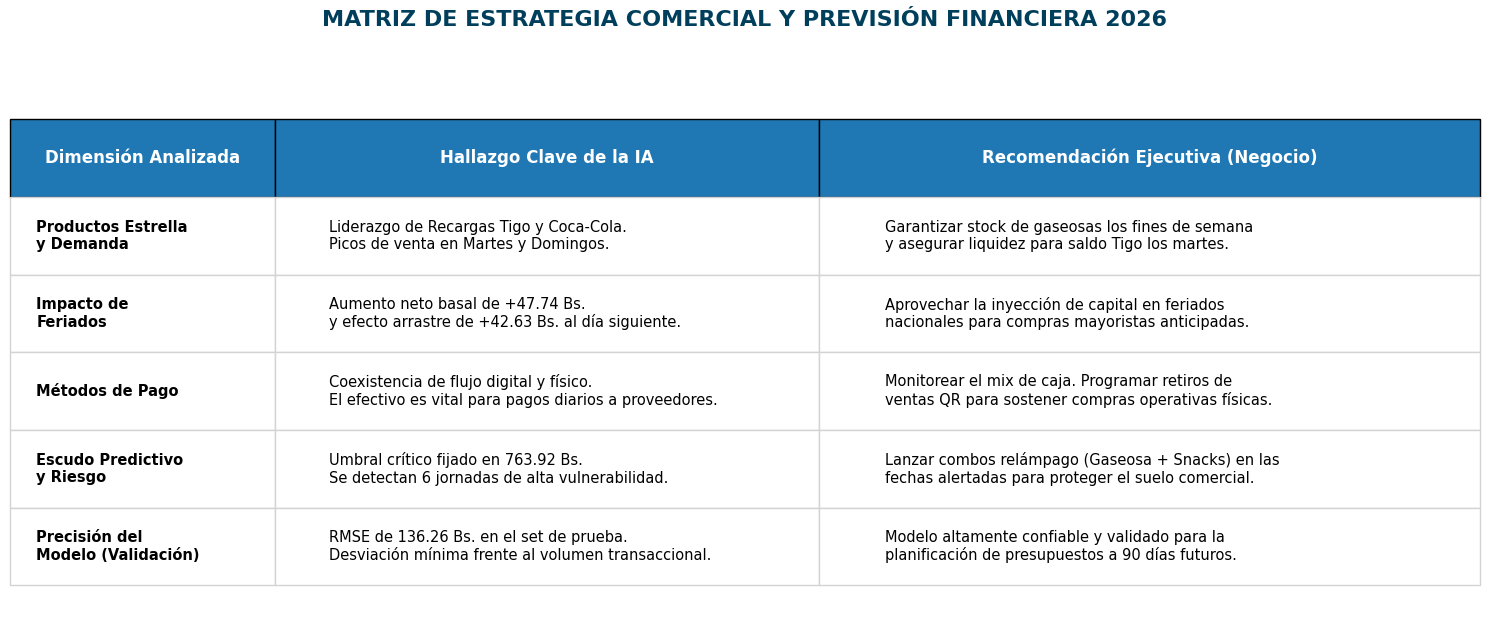

In [ ]:
# Datos extraídos de los resultados reales de tu modelo Prophet para Doña Eva
datos_conclusiones = [
    ["Productos Estrella\ny Demanda",
     "Liderazgo de Recargas Tigo y Coca-Cola.\nPicos de venta en Martes y Domingos.",
     "Garantizar stock de gaseosas los fines de semana\ny asegurar liquidez para saldo Tigo los martes."],

    ["Impacto de\nFeriados",
     "Aumento neto basal de +47.74 Bs.\ny efecto arrastre de +42.63 Bs. al día siguiente.",
     "Aprovechar la inyección de capital en feriados\nnacionales para compras mayoristas anticipadas."],

    ["Métodos de Pago",
     "Coexistencia de flujo digital y físico.\nEl efectivo es vital para pagos diarios a proveedores.",
     "Monitorear el mix de caja. Programar retiros de\nventas QR para sostener compras operativas físicas."],

    ["Escudo Predictivo\ny Riesgo",
     "Umbral crítico fijado en 763.92 Bs.\nSe detectan 6 jornadas de alta vulnerabilidad.",
     "Lanzar combos relámpago (Gaseosa + Snacks) en las\nfechas alertadas para proteger el suelo comercial."],

    ["Precisión del\nModelo (Validación)",
     "RMSE de 136.26 Bs. en el set de prueba.\nDesviación mínima frente al volumen transaccional.",
     "Modelo altamente confiable y validado para la\nplanificación de presupuestos a 90 días futuros."]
]

# Crear la figura con dimensiones óptimas para la lectura
fig, ax = plt.subplots(figsize=(15, 6.5))
ax.set_axis_off()

# Crear la tabla con anchos de columna equilibrados para el texto largo
tabla = ax.table(cellText=datos_conclusiones,
                 colLabels=["Dimensión Analizada", "Hallazgo Clave de la IA", "Recomendación Ejecutiva (Negocio)"],
                 cellLoc='left',
                 loc='center',
                 colWidths=[0.18, 0.37, 0.45],
                 colColours=["#1f77b4", "#1f77b4", "#1f77b4"]) # Azul corporativo elegante

# Estilizar y escalar la tabla
tabla.auto_set_font_size(False)
tabla.set_fontsize(10.5)
tabla.scale(1, 4.2) # Escalado vertical para dar aire a los textos con saltos de línea

# Formatear encabezados y celdas
for (row, col), cell in tabla.get_celld().items():
    # Estilo para los encabezados de columna
    if row == 0:
        cell.get_text().set_color('white')
        cell.get_text().set_weight('bold')
        cell.get_text().set_fontsize(12)
        cell.set_text_props(ha='center')
    # Añadir un ligero alineado y espacio interno a las celdas de contenido
    elif row > 0:
        cell.set_edgecolor('#d3d3d3') # Bordes grises suaves menos agresivos
        if col == 0:
            cell.get_text().set_weight('bold') # Resaltar la primera columna

# Título formal de la sección
plt.title("MATRIZ DE ESTRATEGIA COMERCIAL Y PREVISIÓN FINANCIERA 2026",
          fontsize=16, fontweight='bold', pad=35, color='#003f5c')

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# PIPELINE: CONSOLIDACIÓN Y EXPORTACIÓN DE PREDICCIONES PARA TABLEAU PUBLIC
# ==============================================================================
import pandas as pd

print("⏳ Iniciando la consolidación del dataset predictivo...")

# 1. Base Principal: El pronóstico macro con el Escudo Comercial
# Filtramos para que solo contenga los 90 días desde hoy (21 de mayo de 2026) en adelante
fecha_hoy = pd.to_datetime('2026-05-21')
df_tableau = forecast_real[forecast_real['ds'] >= fecha_hoy][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
df_tableau.columns = ['Fecha', 'Venta_Proyectada', 'Venta_Minima', 'Venta_Maxima']

# Añadir columna indicadora para el Escudo de Baja Venta (Umbral: 763.92 Bs)
df_tableau['Alerta_Escudo'] = df_tableau['Venta_Proyectada'].apply(lambda x: 'DÍA CRÍTICO' if x <= 763.92 else 'NORMAL')

# 2. Acoplar la Opción 1: Ganancia Neta Global
df_gan_filt = proyeccion_ganancias_futuras[['ds', 'yhat']].copy()
df_gan_filt.columns = ['Fecha', 'Ganancia_Neta_Proyectada']
df_tableau = pd.merge(df_tableau, df_gan_filt, on='Fecha', how='left')

# 3. Acoplar la Opción 2: Suministro por Categorías Críticas
# Traemos las proyecciones individuales que guardamos en el diccionario
for cat, df_cat_fut in proyecciones_categorias.items():
    df_cat_filt = df_cat_fut[['ds', 'yhat']].copy()
    # Limpiamos el nombre de la columna para Tableau
    col_name = f"Cat_{cat.replace(' ', '_')}_Proyectado"
    df_cat_filt.columns = ['Fecha', col_name]
    df_tableau = pd.merge(df_tableau, df_cat_filt, on='Fecha', how='left')

# 4. Acoplar la Opción 3: Métodos de Pago (Efectivo vs QR)
for met, df_met_fut in proyecciones_pagos.items():
    df_met_filt = df_met_fut[['ds', 'yhat']].copy()
    col_name = f"Pago_{met.replace(' ', '_')}_Proyectado"
    df_met_filt.columns = ['Fecha', col_name]
    df_tableau = pd.merge(df_tableau, df_met_filt, on='Fecha', how='left')

# 5. Redondear valores a 2 decimales para que se vea limpio en Tableau
columnas_numericas = df_tableau.select_dtypes(include=['float64']).columns
df_tableau[columnas_numericas] = df_tableau[columnas_numericas].round(2)

# 6. EXPORTACIÓN FINAL A ARCHIVO LOCAL
nombre_archivo = 'SmartRetail_Forecasting_DonaEva.csv'
df_tableau.to_csv(nombre_archivo, index=False, encoding='utf-8')

print(f"✅ ¡Dataset preparado con éxito! Archivo guardado como: '{nombre_archivo}'")
print(f"📊 Total de días futuros empaquetados: {len(df_tableau)} días (Horizonte completo a Agosto 2026).")

⏳ Iniciando la consolidación del dataset predictivo...
✅ ¡Dataset preparado con éxito! Archivo guardado como: 'SmartRetail_Forecasting_DonaEva.csv'
📊 Total de días futuros empaquetados: 40 días (Horizonte completo a Agosto 2026).


In [ ]:
# FORZAR LA DESCARGA AUTOMÁTICA DEL CSV AL NAVEGADOR
from google.colab import files

# Esto ordenará a tu navegador web descargar el archivo interno a tu laptop
files.download('SmartRetail_Forecasting_DonaEva.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Enlace TABLEAU

https://public.tableau.com/views/SmartRetail_Prophet_Predictivo_DoaEva/DashboarddeInteligenciaComercial-DoaEva?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

#Enlace Power BI

https://app.powerbi.com/view?r=eyJrIjoiYWU4YmU3YjItOTY3OC00NzU0LTk5NTUtYmU3ZDFiYzQ3ZTI5IiwidCI6IjM4OWZkYjUxLTVlZWQtNGE5MC1hZTA2LWFhNTM3NDUwMDMwNiJ9